In [1]:
# Mount Google Drive to access our dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install any missing libraries
!pip install -q pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# Load the dataset from Google Drive
DATA_PATH = '/content/drive/MyDrive/Churn_Hackathon/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and null values
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


/tmp/ipykernel_623/4059327707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


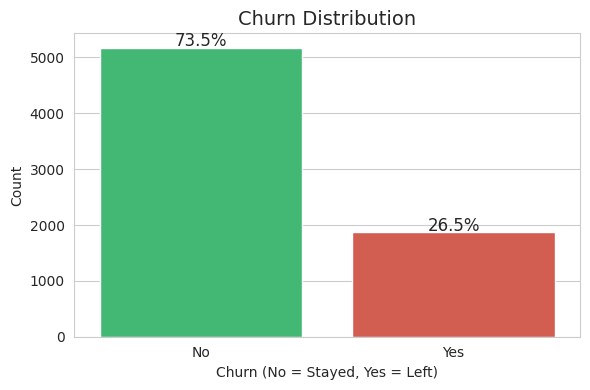

Churn Rate: 26.54%


In [5]:
# How many customers churned vs stayed?
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Count')

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Churn_Hackathon/data/churn_distribution.png', dpi=150)
plt.show()
print(f"Churn Rate: {churn_counts['Yes']/total*100:.2f}%")

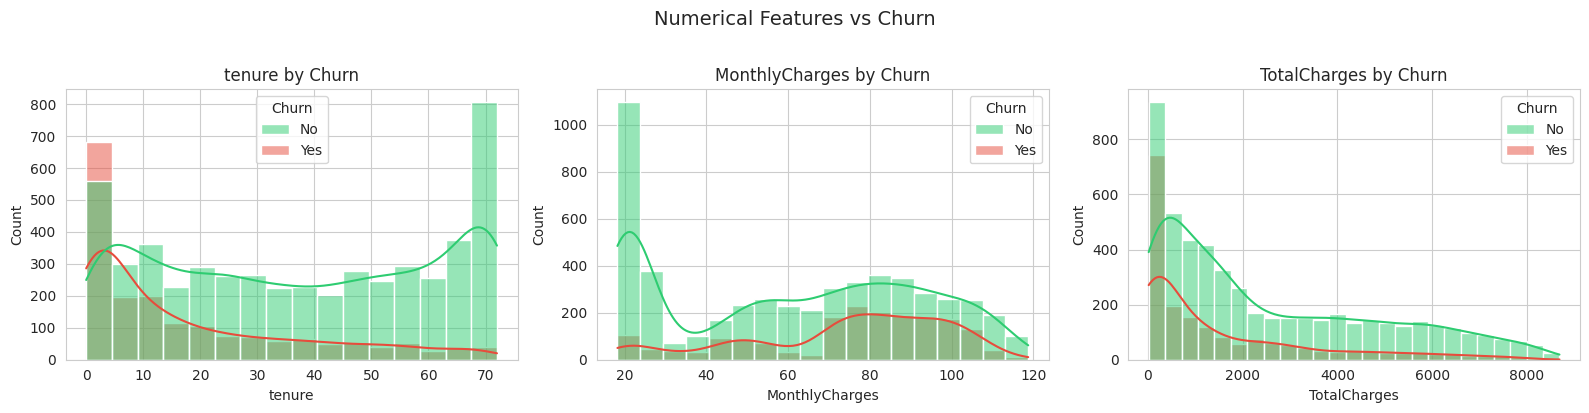

In [6]:
# Distribution of numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# TotalCharges has spaces — fix it first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} by Churn')

plt.suptitle('Numerical Features vs Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Churn_Hackathon/data/numerical_features.png', dpi=150)
plt.show()

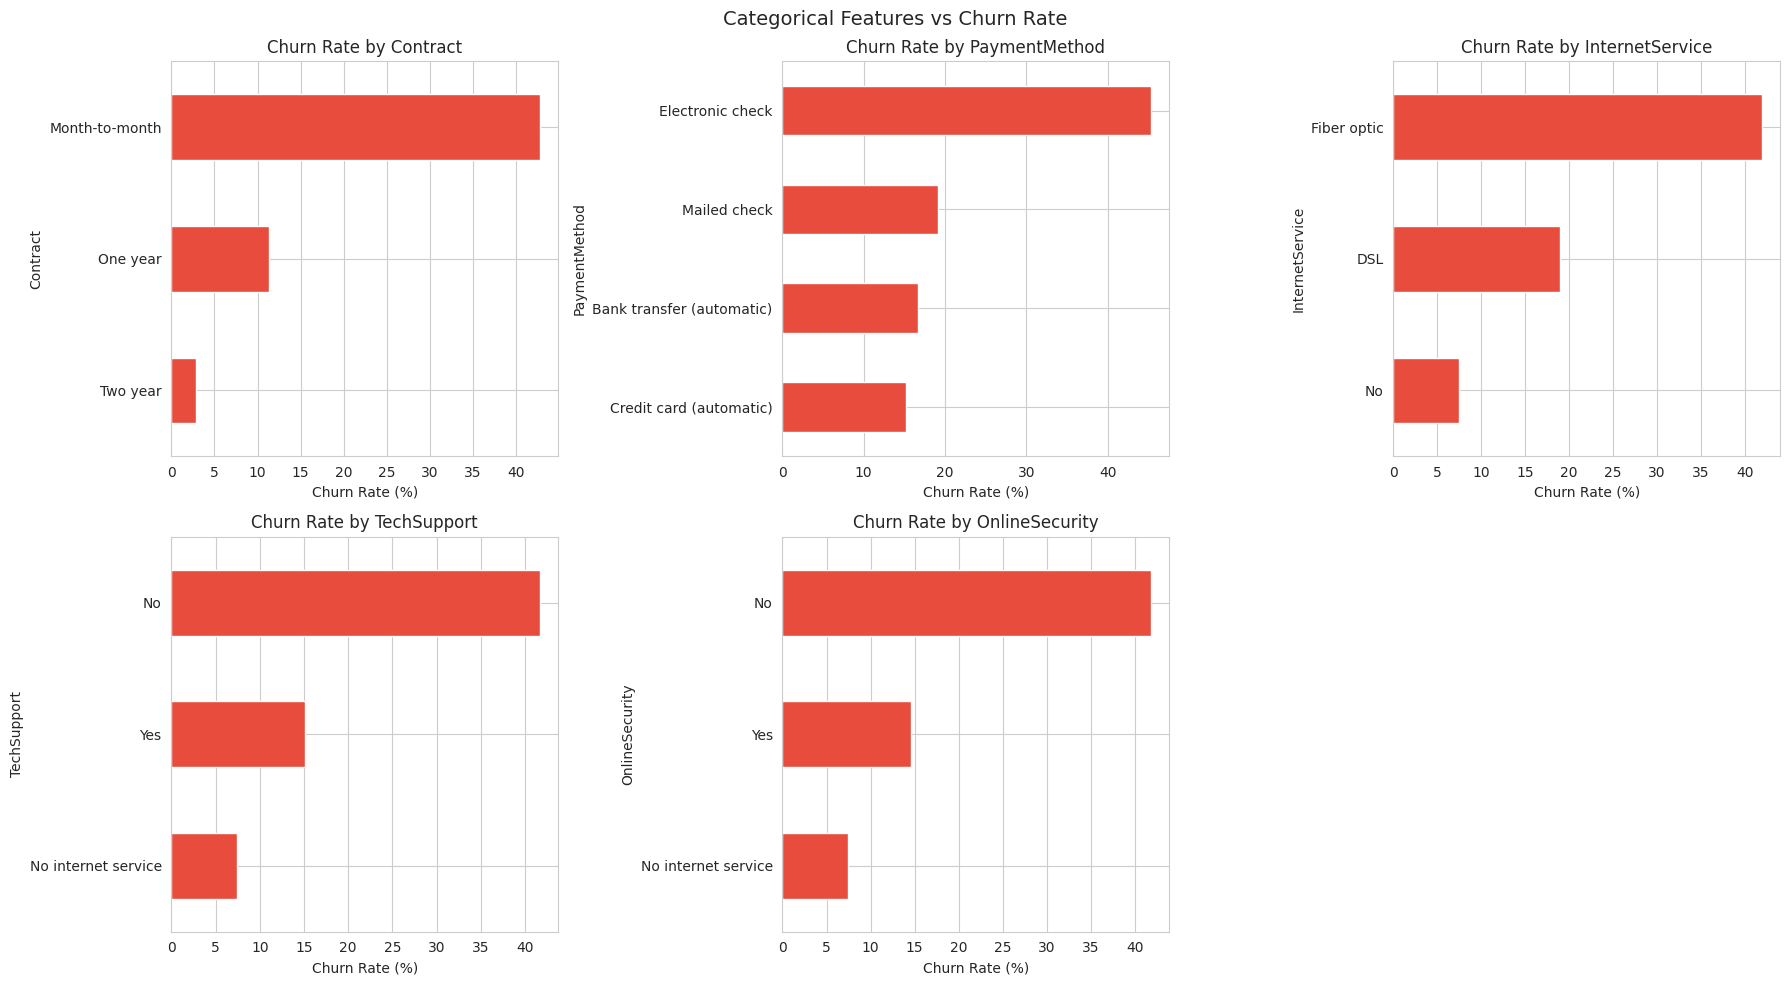

In [7]:
# Top categorical columns to explore
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=axes[i], color='#e74c3c')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('Churn Rate (%)')

axes[5].axis('off')  # hide the extra subplot
plt.suptitle('Categorical Features vs Churn Rate', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Churn_Hackathon/data/categorical_features.png', dpi=150)
plt.show()

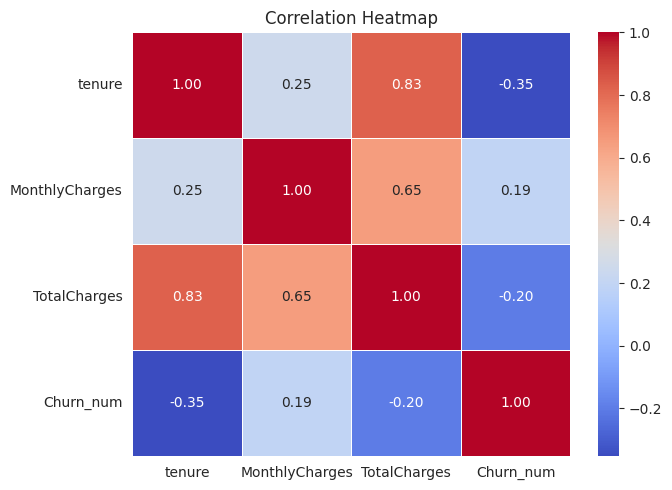

In [8]:
# Correlation heatmap for numerical features
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Churn_Hackathon/data/correlation_heatmap.png', dpi=150)
plt.show()